In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (8,5)
sns.set()

df = pd.read_csv("Hotel_bookings_final.csv")
df.head()

,customer_id,property_id,city,star_rating,booking_date,check_in_date,check_out_date,room_type,num_rooms_booked,stay_type,booking_channel,booking_value,costprice,markup,selling_price,payment_method,refund_status,refund_amount,channel_of_booking,booking_status,travel_date,cashback,coupon_redeem,Coupon USed?
0,492,3,San Francisco,4,2024-04-01,2024-05-24,2024-05-26,Standard,1,Leisure,Mobile App,19361.0,19361,5981,25342,PayPal,Yes,369.648995,Web,Confirmed,2024-03-04,5.374694,0.000000,No
1,180,3,Dallas,3,2024-04-01,2024-05-10,2024-05-17,Deluxe,1,Leisure,Mobile App,6137.0,6137,1896,8033,Bank Transfer,Yes,492.505903,Web,Confirmed,2024-07-19,7.161033,0.000000,No
2,50,5,Dallas,3,2024-04-01,2024-05-31,2024-06-05,Deluxe,1,Business,Web,22702.0,22702,7013,29715,Debit Card,Yes,0.000000,iOS,Confirmed,2024-03-22,0.000000,0.000000,No
3,294,3,Orlando,4,2024-04-01,2024-04-18,2024-04-24,Deluxe,3,Leisure,Web,34068.0,34068,10524,44592,Bank Transfer,Yes,545.541516,Android,Confirmed,2024-11-24,7.932170,24.500442,Yes
4,40,5,Seattle,5,2024-04-01,NaN,NaN,Deluxe,1,Leisure,Mobile App,12127.0,12127,3746,15873,Debit Card,Yes,211.367602,Web,Cancelled,2024-03-02,0.000000,0.000000,No


In [2]:
df.shape

(30000, 24)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         30000 non-null  int64  
 1   property_id         30000 non-null  int64  
 2   city                30000 non-null  object 
 3   star_rating         30000 non-null  int64  
 4   booking_date        30000 non-null  object 
 5   check_in_date       24532 non-null  object 
 6   check_out_date      24532 non-null  object 
 7   room_type           30000 non-null  object 
 8   num_rooms_booked    30000 non-null  int64  
 9   stay_type           30000 non-null  object 
 10  booking_channel     30000 non-null  object 
 11  booking_value       30000 non-null  float64
 12  costprice           30000 non-null  int64  
 13  markup              30000 non-null  int64  
 14  selling_price       30000 non-null  int64  
 15  payment_method      30000 non-null  object 
 16  refu

In [4]:
df.describe()

,customer_id,property_id,star_rating,num_rooms_booked,booking_value,costprice,markup,selling_price,refund_amount,cashback,coupon_redeem
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,249.721767,3.777533,3.602033,1.352333,25080.525454,22541.494100,6963.32440,29504.818500,320.938376,3.831534,4.134988
std,145.484836,2.081471,0.860241,0.574403,11587.369335,9259.520787,2860.10657,12119.627338,339.635396,4.783590,10.846221
min,1.000000,1.000000,2.000000,1.000000,1279.770000,3822.000000,1181.00000,5003.000000,0.000000,0.000000,-3.532183
25%,123.000000,1.000000,3.000000,1.000000,15922.712500,15088.750000,4661.75000,19750.500000,0.000000,0.000000,0.000000
50%,248.000000,3.000000,4.000000,1.000000,24736.145000,22731.000000,7021.50000,29752.500000,221.141185,1.030180,0.000000
75%,376.000000,5.000000,4.000000,2.000000,33570.000000,30427.000000,9399.00000,39826.000000,594.624344,7.378533,0.000000
max,499.000000,7.000000,5.000000,3.000000,67764.460000,38200.000000,11800.00000,50000.000000,1462.725105,21.268013,89.644917


In [5]:
df.isnull().sum()

customer_id              0
property_id              0
city                     0
star_rating              0
booking_date             0
check_in_date         5468
check_out_date        5468
room_type                0
num_rooms_booked         0
stay_type                0
booking_channel          0
booking_value            0
costprice                0
markup                   0
selling_price            0
payment_method           0
refund_status            0
refund_amount            0
channel_of_booking       0
booking_status           0
travel_date              0
cashback                 0
coupon_redeem            0
Coupon USed?             0
dtype: int64

In [6]:
df['booking_date'] = pd.to_datetime(df['booking_date'], errors='coerce')
df['check_in_date'] = pd.to_datetime(df['check_in_date'], errors='coerce')
df['check_out_date'] = pd.to_datetime(df['check_out_date'], errors='coerce')
df['travel_date'] = pd.to_datetime(df['travel_date'], errors='coerce')

In [7]:
df.isnull().sum()

customer_id              0
property_id              0
city                     0
star_rating              0
booking_date             0
check_in_date         5468
check_out_date        5468
room_type                0
num_rooms_booked         0
stay_type                0
booking_channel          0
booking_value            0
costprice                0
markup                   0
selling_price            0
payment_method           0
refund_status            0
refund_amount            0
channel_of_booking       0
booking_status           0
travel_date              0
cashback                 0
coupon_redeem            0
Coupon USed?             0
dtype: int64

In [10]:
df['check_in_date'] = df['check_in_date'].fillna(df['travel_date'])

In [11]:
df['check_out_date'] = df['check_out_date'].fillna(df['check_in_date'])

In [12]:
df.isnull().sum()

customer_id           0
property_id           0
city                  0
star_rating           0
booking_date          0
check_in_date         0
check_out_date        0
room_type             0
num_rooms_booked      0
stay_type             0
booking_channel       0
booking_value         0
costprice             0
markup                0
selling_price         0
payment_method        0
refund_status         0
refund_amount         0
channel_of_booking    0
booking_status        0
travel_date           0
cashback              0
coupon_redeem         0
Coupon USed?          0
dtype: int64

In [13]:
df.describe()

,customer_id,property_id,star_rating,booking_date,check_in_date,check_out_date,num_rooms_booked,booking_value,costprice,markup,selling_price,refund_amount,travel_date,cashback,coupon_redeem
count,30000.000000,30000.000000,30000.000000,30000,30000,30000,30000.000000,30000.000000,30000.000000,30000.00000,30000.000000,30000.000000,30000,30000.000000,30000.000000
mean,249.721767,3.777533,3.602033,2024-10-14 12:00:02.880000,2024-10-24 15:16:04.800000256,2024-10-27 21:54:17.279999744,1.352333,25080.525454,22541.494100,6963.32440,29504.818500,320.938376,2024-07-24 03:53:11.040000,3.831534,4.134988
min,1.000000,1.000000,2.000000,2024-04-01 00:00:00,2024-03-02 00:00:00,2024-03-02 00:00:00,1.000000,1279.770000,3822.000000,1181.00000,5003.000000,0.000000,2024-03-02 00:00:00,0.000000,-3.532183
25%,123.000000,1.000000,3.000000,2024-07-08 00:00:00,2024-07-19 00:00:00,2024-07-21 00:00:00,1.000000,15922.712500,15088.750000,4661.75000,19750.500000,0.000000,2024-05-28 00:00:00,0.000000,0.000000
50%,248.000000,3.000000,4.000000,2024-10-14 12:00:00,2024-10-14 00:00:00,2024-10-18 00:00:00,1.000000,24736.145000,22731.000000,7021.50000,29752.500000,221.141185,2024-07-23 00:00:00,1.030180,0.000000
75%,376.000000,5.000000,4.000000,2025-01-21 00:00:00,2025-01-30 00:00:00,2025-02-03 00:00:00,2.000000,33570.000000,30427.000000,9399.00000,39826.000000,594.624344,2024-09-08 00:00:00,7.378533,0.000000
max,499.000000,7.000000,5.000000,2025-04-30 00:00:00,2025-06-28 00:00:00,2025-07-03 00:00:00,3.000000,67764.460000,38200.000000,11800.00000,50000.000000,1462.725105,2025-01-29 00:00:00,21.268013,89.644917
std,145.484836,2.081471,0.860241,NaN,NaN,NaN,0.574403,11587.369335,9259.520787,2860.10657,12119.627338,339.635396,NaN,4.783590,10.846221


In [14]:
df['coupon_redeem'] = df['coupon_redeem'].apply(lambda x: 0 if x < 0 else x)

In [15]:
q1 = df['coupon_redeem'].quantile(0.25)
q3 = df['coupon_redeem'].quantile(0.75)
iqr = q3 - q1

upper_limit = q3 + 1.5 * iqr

df['coupon_redeem'] = np.where(df['coupon_redeem'] > upper_limit, upper_limit, df['coupon_redeem'])

In [16]:
df.describe()

,customer_id,property_id,star_rating,booking_date,check_in_date,check_out_date,num_rooms_booked,booking_value,costprice,markup,selling_price,refund_amount,travel_date,cashback,coupon_redeem
count,30000.000000,30000.000000,30000.000000,30000,30000,30000,30000.000000,30000.000000,30000.000000,30000.00000,30000.000000,30000.000000,30000,30000.000000,30000.0
mean,249.721767,3.777533,3.602033,2024-10-14 12:00:02.880000,2024-10-24 15:16:04.800000256,2024-10-27 21:54:17.279999744,1.352333,25080.525454,22541.494100,6963.32440,29504.818500,320.938376,2024-07-24 03:53:11.040000,3.831534,0.0
min,1.000000,1.000000,2.000000,2024-04-01 00:00:00,2024-03-02 00:00:00,2024-03-02 00:00:00,1.000000,1279.770000,3822.000000,1181.00000,5003.000000,0.000000,2024-03-02 00:00:00,0.000000,0.0
25%,123.000000,1.000000,3.000000,2024-07-08 00:00:00,2024-07-19 00:00:00,2024-07-21 00:00:00,1.000000,15922.712500,15088.750000,4661.75000,19750.500000,0.000000,2024-05-28 00:00:00,0.000000,0.0
50%,248.000000,3.000000,4.000000,2024-10-14 12:00:00,2024-10-14 00:00:00,2024-10-18 00:00:00,1.000000,24736.145000,22731.000000,7021.50000,29752.500000,221.141185,2024-07-23 00:00:00,1.030180,0.0
75%,376.000000,5.000000,4.000000,2025-01-21 00:00:00,2025-01-30 00:00:00,2025-02-03 00:00:00,2.000000,33570.000000,30427.000000,9399.00000,39826.000000,594.624344,2024-09-08 00:00:00,7.378533,0.0
max,499.000000,7.000000,5.000000,2025-04-30 00:00:00,2025-06-28 00:00:00,2025-07-03 00:00:00,3.000000,67764.460000,38200.000000,11800.00000,50000.000000,1462.725105,2025-01-29 00:00:00,21.268013,0.0
std,145.484836,2.081471,0.860241,NaN,NaN,NaN,0.574403,11587.369335,9259.520787,2860.10657,12119.627338,339.635396,NaN,4.783590,0.0


In [17]:
df = pd.read_csv("Hotel_bookings_final.csv")

df['coupon_redeem'] = df['coupon_redeem'].apply(lambda x: 0 if x < 0 else x)

In [18]:
df['coupon_redeem'].describe()

count    30000.000000
mean         4.137669
std         10.844944
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         89.644917
Name: coupon_redeem, dtype: float64

In [19]:
df['booking_date'].describe()

count          30000
unique           395
top       2024-04-01
freq              77
Name: booking_date, dtype: object

In [24]:
df['check_in_date'] = pd.to_datetime(df['check_in_date'], errors='coerce')
df['check_out_date'] = pd.to_datetime(df['check_out_date'], errors='coerce')

df['stay_duration'] = (df['check_out_date'] - df['check_in_date']).dt.days

df['stay_duration'].describe()

count    24532.000000
mean         4.006848
std          2.001231
min          1.000000
25%          2.000000
50%          4.000000
75%          6.000000
max          7.000000
Name: stay_duration, dtype: float64

In [25]:
df['stay_duration'].isnull().sum()

np.int64(5468)

In [27]:
df['stay_duration'] = df['stay_duration'].fillna(df['stay_duration'].median())
df['stay_duration'].isnull().sum()

np.int64(0)

In [29]:
df['is_cancelled'] = df['booking_status'].apply(lambda x: 1 if str(x).lower() in ['cancelled','canceled'] else 0)
df['is_cancelled'].mean()

np.float64(0.20233333333333334)

# Analysis bases on Booking channel

In [30]:
df['booking_channel'].value_counts()

booking_channel
Web             15001
Mobile App      12009
Travel Agent     2990
Name: count, dtype: int64

In [31]:
df.groupby('booking_channel')['is_cancelled'].mean()

booking_channel
Mobile App      0.215588
Travel Agent    0.279264
Web             0.176388
Name: is_cancelled, dtype: float64

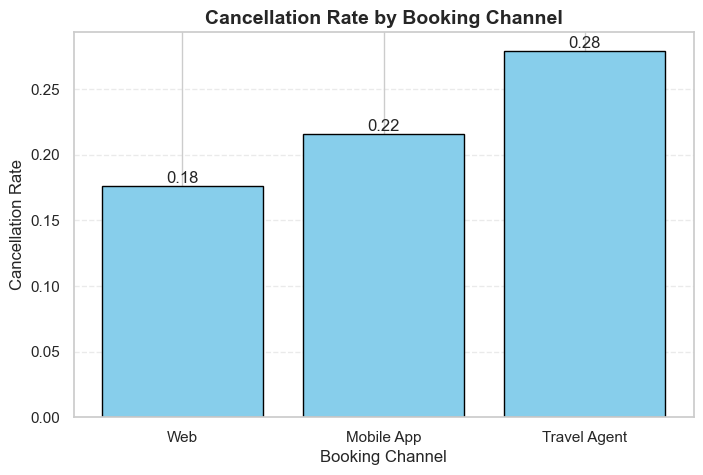

In [74]:
data = df.groupby('booking_channel')['is_cancelled'].mean().sort_values()

plt.figure(figsize=(8,5))

plt.bar(
    data.index,
    data.values,
    color='skyblue',
    edgecolor='black'
)

plt.title("Cancellation Rate by Booking Channel", fontsize=14, fontweight='bold')
plt.xlabel("Booking Channel")
plt.ylabel("Cancellation Rate")

# value labels
for i, v in enumerate(data.values):
    plt.text(i, v, f"{v:.2f}", ha='center', va='bottom')

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

In [40]:
df.groupby('booking_channel')['booking_value'].mean()

booking_channel
Mobile App      21351.285716
Travel Agent    24453.972990
Web             28190.840225
Name: booking_value, dtype: float64

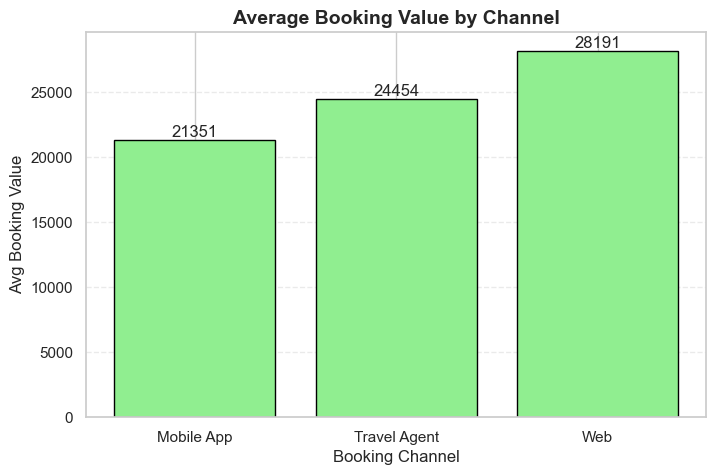

In [75]:
data = df.groupby('booking_channel')['booking_value'].mean().sort_values()

plt.figure(figsize=(8,5))

plt.bar(
    data.index,
    data.values,
    color='lightgreen',
    edgecolor='black'
)

plt.title("Average Booking Value by Channel", fontsize=14, fontweight='bold')
plt.xlabel("Booking Channel")
plt.ylabel("Avg Booking Value")

# value labels on bars
for i, v in enumerate(data.values):
    plt.text(i, v, f"{v:.0f}", ha='center', va='bottom')

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

# Analysis based on room type

In [32]:
df['room_type'].value_counts()

room_type
Standard    16552
Deluxe      10478
Suite        2970
Name: count, dtype: int64

In [33]:
df.groupby('room_type')['is_cancelled'].mean()

room_type
Deluxe      0.160241
Standard    0.233023
Suite       0.179798
Name: is_cancelled, dtype: float64

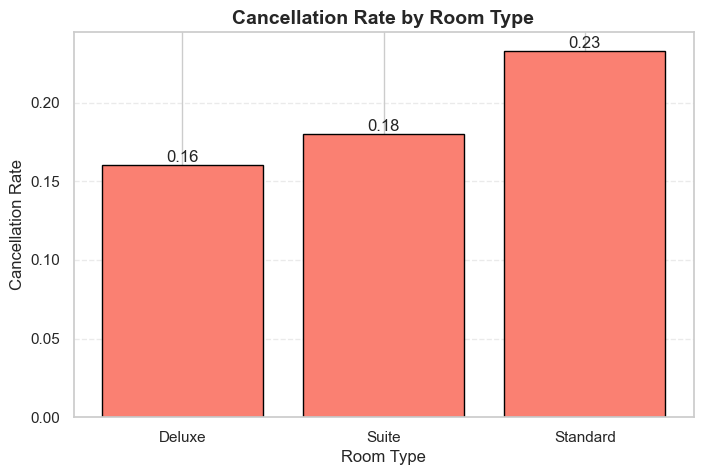

In [76]:
data = df.groupby('room_type')['is_cancelled'].mean().sort_values()

plt.figure(figsize=(8,5))

plt.bar(
    data.index,
    data.values,
    color='salmon',
    edgecolor='black'
)

plt.title("Cancellation Rate by Room Type", fontsize=14, fontweight='bold')
plt.xlabel("Room Type")
plt.ylabel("Cancellation Rate")

# value labels
for i, v in enumerate(data.values):
    plt.text(i, v, f"{v:.2f}", ha='center', va='bottom')

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

In [59]:
df.groupby('room_type')['booking_value'].mean()

room_type
Deluxe      25004.565025
Standard    25146.970413
Suite       24978.207751
Name: booking_value, dtype: float64

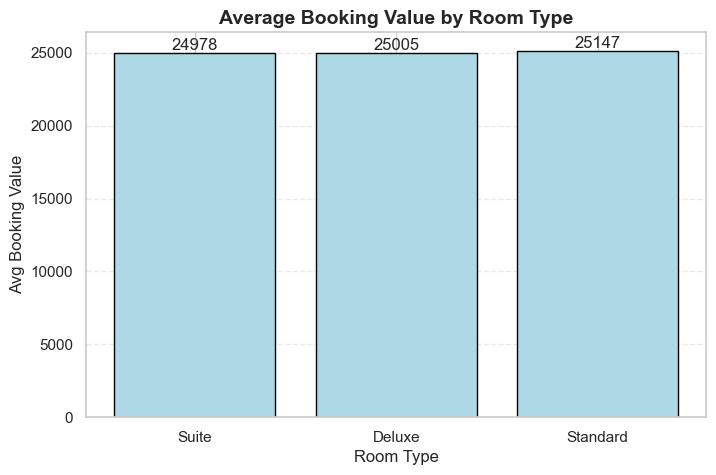

In [77]:
data = df.groupby('room_type')['booking_value'].mean().sort_values()

plt.figure(figsize=(8,5))

plt.bar(
    data.index,
    data.values,
    color='lightblue',
    edgecolor='black'
)

plt.title("Average Booking Value by Room Type", fontsize=14, fontweight='bold')
plt.xlabel("Room Type")
plt.ylabel("Avg Booking Value")

# value labels
for i, v in enumerate(data.values):
    plt.text(i, v, f"{v:.0f}", ha='center', va='bottom')

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

# Analysis based on Star Rating

In [34]:
df['star_rating'].value_counts()

star_rating
4    12034
3    10460
5     4511
2     2995
Name: count, dtype: int64

In [35]:
df.groupby('star_rating')['is_cancelled'].mean()

star_rating
2    0.197663
3    0.202008
4    0.199934
5    0.212591
Name: is_cancelled, dtype: float64

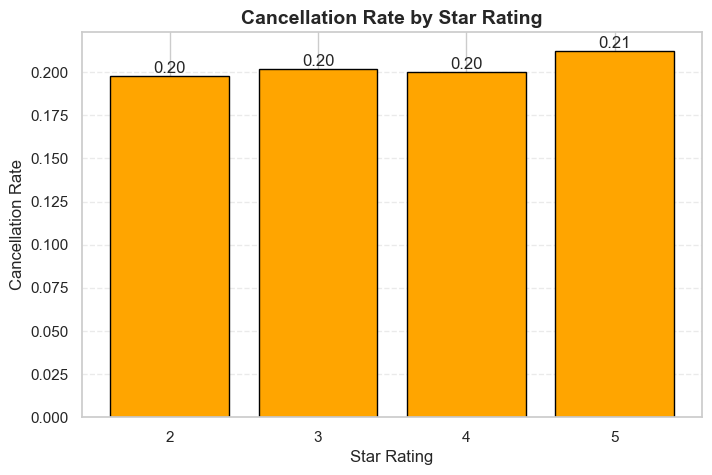

In [87]:
import matplotlib.pyplot as plt

data = df.groupby('star_rating')['is_cancelled'].mean().sort_index()

plt.figure(figsize=(8,5))

plt.bar(
    data.index,
    data.values,
    color='orange',
    edgecolor='black'
)

plt.title("Cancellation Rate by Star Rating", fontsize=14, fontweight='bold')
plt.xlabel("Star Rating")
plt.ylabel("Cancellation Rate")

for i, v in enumerate(data.values):
    plt.text(data.index[i], v, f"{v:.2f}", ha='center', va='bottom')

plt.xticks(data.index)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

In [44]:
df.groupby('star_rating')['booking_value'].mean()

star_rating
2    24855.819716
3    25209.567736
4    25010.623536
5    25116.972161
Name: booking_value, dtype: float64

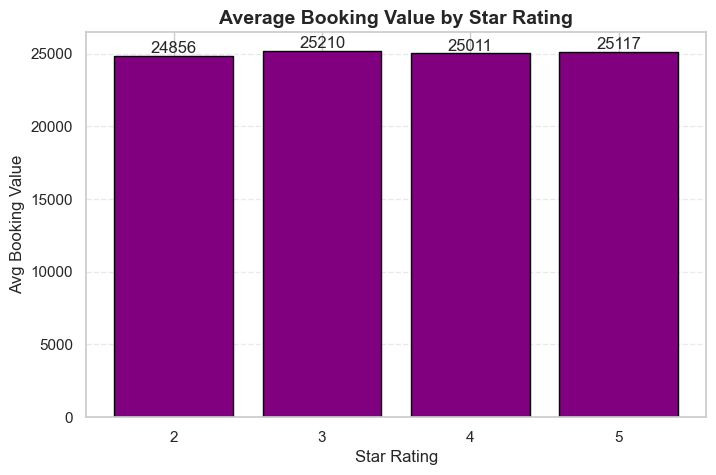

In [88]:
import matplotlib.pyplot as plt

data = df.groupby('star_rating')['booking_value'].mean().sort_index()

plt.figure(figsize=(8,5))

plt.bar(
    data.index,
    data.values,
    color='purple',
    edgecolor='black'
)

plt.title("Average Booking Value by Star Rating", fontsize=14, fontweight='bold')
plt.xlabel("Star Rating")
plt.ylabel("Avg Booking Value")

for i, v in enumerate(data.values):
    plt.text(data.index[i], v, f"{v:.0f}", ha='center', va='bottom')

plt.xticks(data.index)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

# Seasonal Trends 

In [46]:
df['booking_date'] = pd.to_datetime(df['booking_date'], errors='coerce')
df['month'] = df['booking_date'].dt.month

In [47]:
df.groupby('month').size()

month
1     2360
2     2132
3     2360
4     4494
5     2360
6     2284
7     2361
8     2360
9     2284
10    2360
11    2285
12    2360
dtype: int64

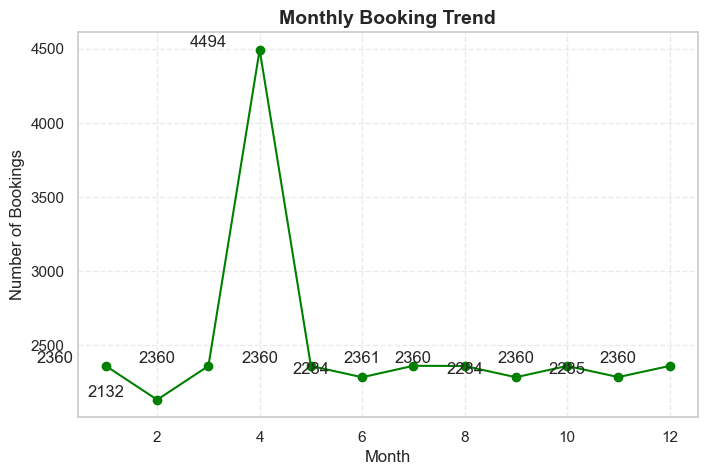

In [82]:
data = df.groupby('month').size().sort_index()

plt.figure(figsize=(8,5))

plt.plot(
    data.index,
    data.values,
    marker='o',
    color='green'
)

plt.title("Monthly Booking Trend", fontsize=14, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Number of Bookings")

# value labels
for i, v in enumerate(data.values):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

In [48]:
df.groupby('month')['booking_value'].mean()

month
1     23424.240288
2     27806.446412
3     27316.317513
4     25116.494933
5     23197.152432
6     24202.785705
7     25501.593859
8     26064.735975
9     24635.105197
10    24880.617462
11    25753.245326
12    23276.987242
Name: booking_value, dtype: float64

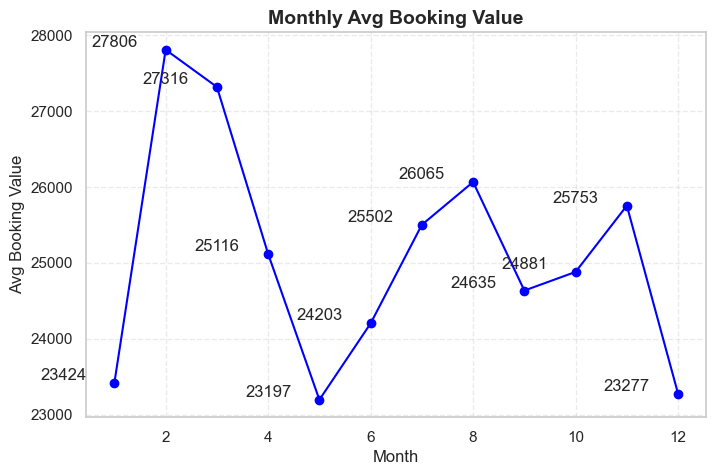

In [83]:
data = df.groupby('month')['booking_value'].mean().sort_index()

plt.figure(figsize=(8,5))

plt.plot(
    data.index,
    data.values,
    marker='o',
    color='blue'
)

plt.title("Monthly Avg Booking Value", fontsize=14, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Avg Booking Value")

# value labels
for i, v in enumerate(data.values):
    plt.text(i, v, f"{v:.0f}", ha='center', va='bottom')

plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

In [51]:
df.groupby('month')['is_cancelled'].mean()

month
1     0.236864
2     0.174953
3     0.175847
4     0.163106
5     0.172881
6     0.175131
7     0.303261
8     0.287712
9     0.177320
10    0.173729
11    0.159300
12    0.257627
Name: is_cancelled, dtype: float64

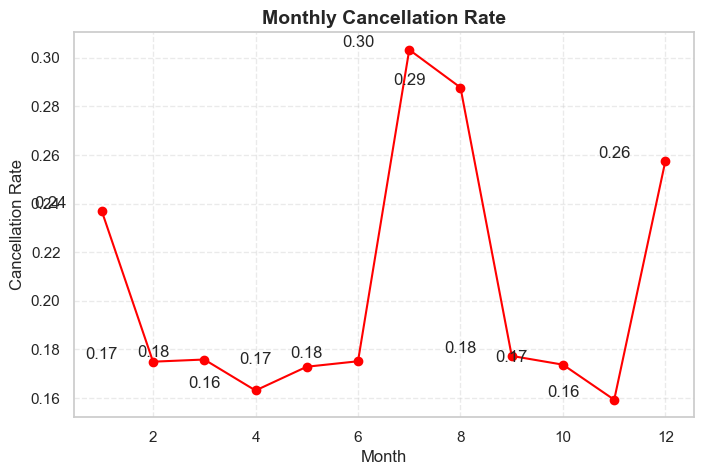

In [84]:
data = df.groupby('month')['is_cancelled'].mean().sort_index()

plt.figure(figsize=(8,5))

plt.plot(
    data.index,
    data.values,
    marker='o',
    color='red'
)

plt.title("Monthly Cancellation Rate", fontsize=14, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Cancellation Rate")

# value labels
for i, v in enumerate(data.values):
    plt.text(i, v, f"{v:.2f}", ha='center', va='bottom')

plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

# Trends based on Cancellation

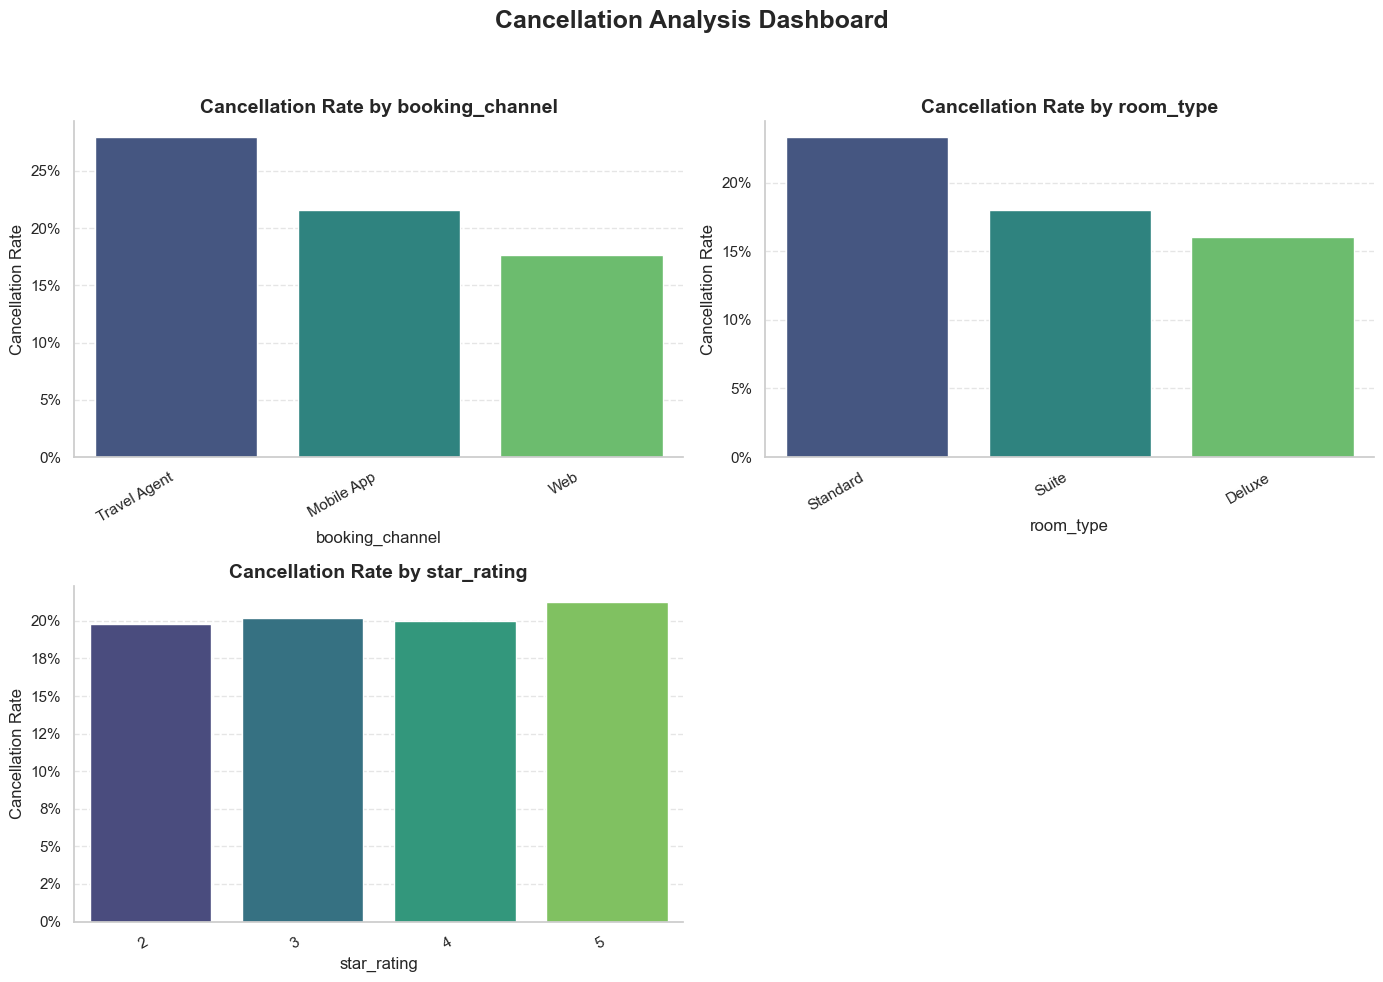

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

cat_cols = ['booking_channel', 'room_type', 'star_rating']

num_rows = 2
fig, axes = plt.subplots(num_rows, 2, figsize=(14, 10))

axes = axes.flatten()

for i, cat_col in enumerate(cat_cols):
    
    # Calculate cancellation rate
    temp = df.groupby(cat_col)['is_cancelled'].mean().reset_index()
    temp = temp.sort_values(by='is_cancelled', ascending=False)

    sns.barplot(
        x=cat_col,
        y='is_cancelled',
        data=temp,
        ax=axes[i],
        palette='viridis',
        ci=None
    )

    axes[i].set_title(f'Cancellation Rate by {cat_col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(cat_col)
    axes[i].set_ylabel('Cancellation Rate')

    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha='right')

    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)


for i in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[i])

plt.suptitle("Cancellation Analysis Dashboard", fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

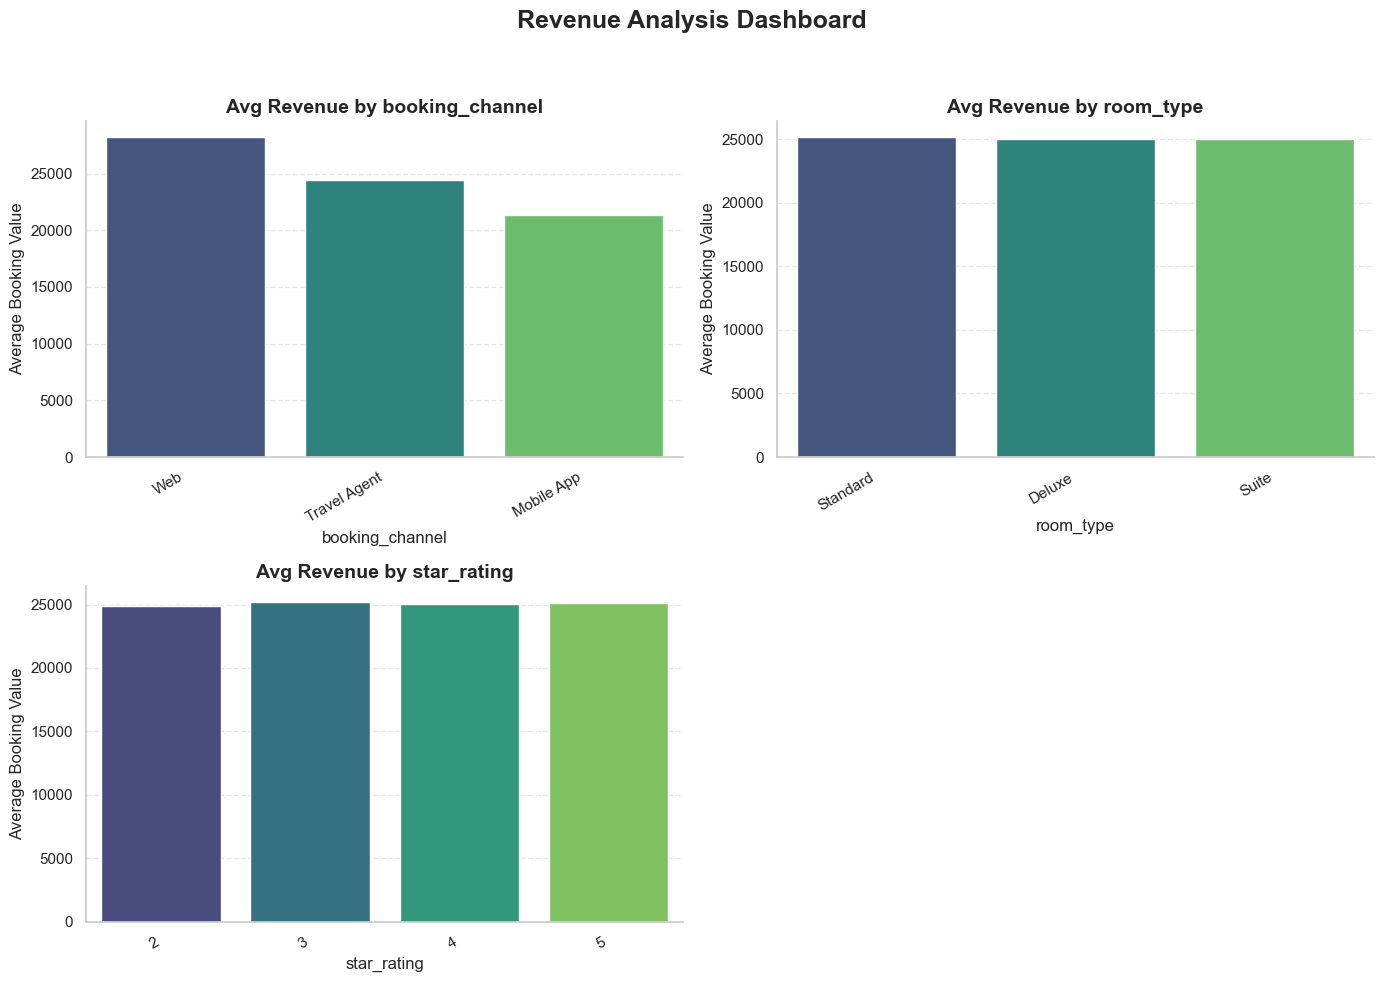

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

cat_cols = ['booking_channel', 'room_type', 'star_rating']

num_rows = 2
fig, axes = plt.subplots(num_rows, 2, figsize=(14, 10))
axes = axes.flatten()

for i, cat_col in enumerate(cat_cols):
    
    # Compute average booking value
    temp = df.groupby(cat_col)['booking_value'].mean().reset_index()
    temp = temp.sort_values(by='booking_value', ascending=False)

    sns.barplot(
        x=cat_col,
        y='booking_value',
        data=temp,
        ax=axes[i],
        palette='viridis',
        ci=None
    )

    axes[i].set_title(f'Avg Revenue by {cat_col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(cat_col)
    axes[i].set_ylabel('Average Booking Value')

    axes[i].grid(axis='y', linestyle='--', alpha=0.5)


    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha='right')


    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

for i in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[i])

plt.suptitle("Revenue Analysis Dashboard", fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

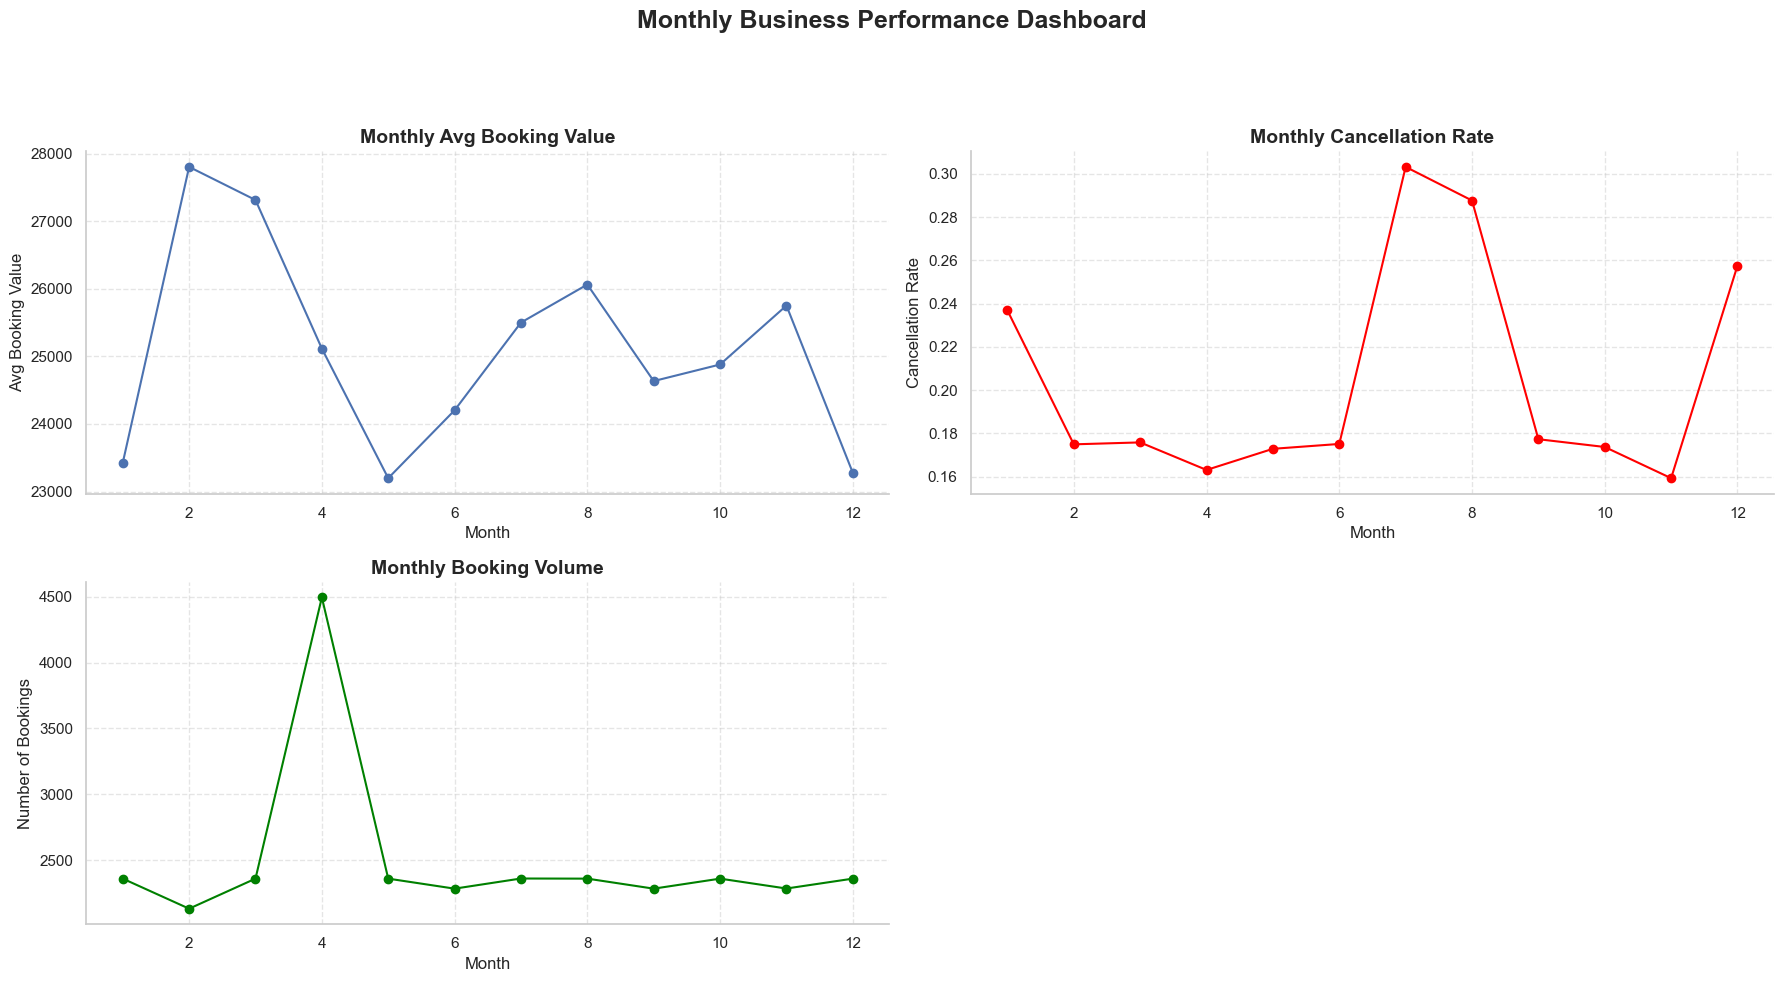

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

df.groupby('month')['booking_value'].mean().plot(
    kind='line',
    marker='o',
    ax=axes[0, 0]
)

axes[0, 0].set_title("Monthly Avg Booking Value", fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel("Month")
axes[0, 0].set_ylabel("Avg Booking Value")
axes[0, 0].grid(True, linestyle='--', alpha=0.5)


df.groupby('month')['is_cancelled'].mean().plot(
    kind='line',
    marker='o',
    ax=axes[0, 1],
    color='red'
)

axes[0, 1].set_title("Monthly Cancellation Rate", fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel("Month")
axes[0, 1].set_ylabel("Cancellation Rate")
axes[0, 1].grid(True, linestyle='--', alpha=0.5)


df.groupby('month').size().plot(
    kind='line',
    marker='o',
    ax=axes[1, 0],
    color='green'
)

axes[1, 0].set_title("Monthly Booking Volume", fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel("Month")
axes[1, 0].set_ylabel("Number of Bookings")
axes[1, 0].grid(True, linestyle='--', alpha=0.5)


fig.delaxes(axes[1, 1])

for ax in fig.axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle("Monthly Business Performance Dashboard", fontsize=18, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

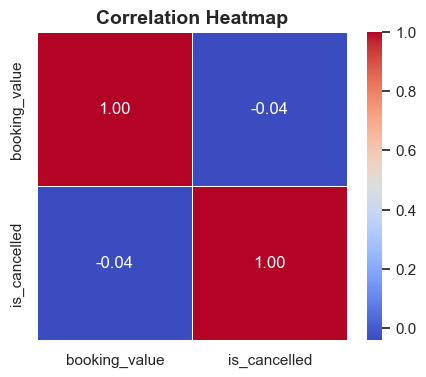

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

num_df = df[['booking_value', 'is_cancelled']].copy()

corr = num_df.corr()

plt.figure(figsize=(5,4))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap", fontsize=14, fontweight='bold')
plt.show()

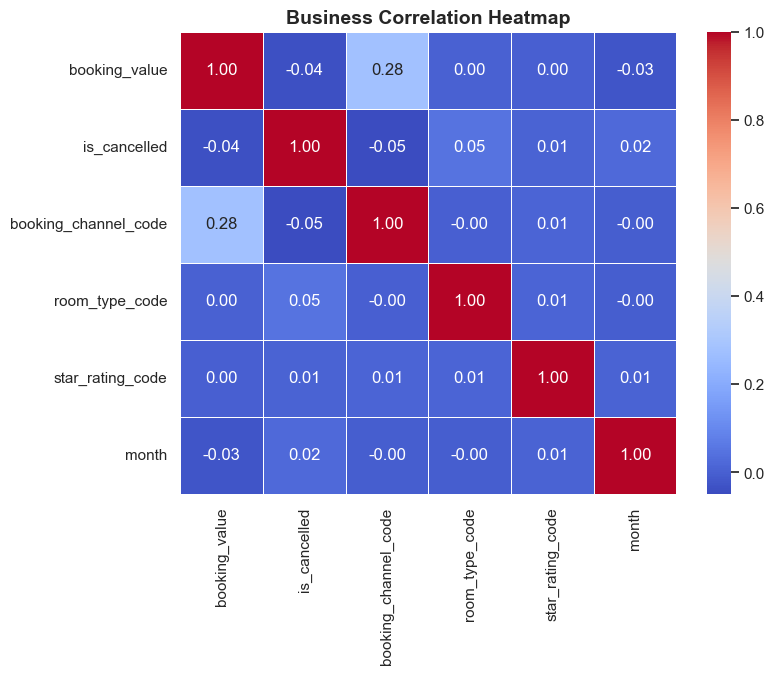

In [86]:
df_corr = df.copy()

df_corr['month'] = df_corr['month'].astype(int)

df_corr['booking_channel_code'] = df_corr['booking_channel'].astype('category').cat.codes
df_corr['room_type_code'] = df_corr['room_type'].astype('category').cat.codes
df_corr['star_rating_code'] = df_corr['star_rating'].astype('category').cat.codes

cols = [
    'booking_value',
    'is_cancelled',
    'booking_channel_code',
    'room_type_code',
    'star_rating_code',
    'month'
]

corr = df_corr[cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5, fmt=".2f")

plt.title("Business Correlation Heatmap", fontsize=14, fontweight='bold')
plt.show()